In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.getcwd()))

from experts_opinion_agent import build_agent, interviewBuilder

agent = build_agent()
builder = interviewBuilder()

graph = agent.get_graph()
builder_graph = builder.get_graph()

print(f"Agent compiled. Nodes: {list(agent.nodes.keys())}")
print(f"Builder compiled. Nodes: {list(builder_graph.nodes.keys())}")

Agent compiled. Nodes: ['__start__', 'create_analysts', 'conduct_interview', 'write_decision', 'build_decision']
Builder compiled. Nodes: ['__start__', 'ask_question', 'search_web', 'answer_question', 'save_interview', 'write_opinion', '__end__']


In [2]:
from IPython.display import Markdown

builder_mermaid_code = builder_graph.draw_mermaid()
display(Markdown(f"```mermaid\n{builder_mermaid_code}\n```"))

mermaid_code = graph.draw_mermaid()
display(Markdown(f"```mermaid\n{mermaid_code}\n```"))


```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	ask_question(ask_question)
	search_web(search_web)
	answer_question(answer_question)
	save_interview(save_interview)
	write_opinion(write_opinion)
	__end__([<p>__end__</p>]):::last
	__start__ --> ask_question;
	answer_question -.-> ask_question;
	answer_question -.-> save_interview;
	ask_question --> search_web;
	save_interview --> write_opinion;
	search_web --> answer_question;
	write_opinion --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

```mermaid
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	create_analysts(create_analysts)
	conduct_interview(conduct_interview)
	write_decision(write_decision)
	build_decision(build_decision)
	__end__([<p>__end__</p>]):::last
	__start__ --> create_analysts;
	conduct_interview --> write_decision;
	create_analysts -.-> conduct_interview;
	write_decision --> build_decision;
	build_decision --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

```

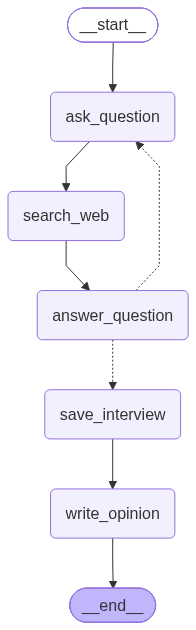

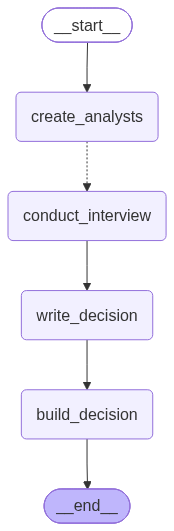

In [3]:
from IPython.display import Image

builder_png_data = builder_graph.draw_mermaid_png()
display(Image(builder_png_data))

png_data = graph.draw_mermaid_png()
display(Image(png_data))

## Deep Test (stream, 3 analysts)

In [4]:
# Inputs
max_analysts = 3
topic = "Will Kamala Harris be the Democratic party presidential candidate in 2028?"
thread = {"configurable": {"thread_id": "1"}}

# Run the graph and stream all events
for event in agent.stream(
    {
        "topic":topic, 
        "max_analysts":max_analysts,
    }, 
    thread, 
    stream_mode="values"
):
    
    # Print analysts
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)
    
    # Print messages from interviews
    messages = event.get('messages', [])
    if messages:
        last_msg = messages[-1]
        if hasattr(last_msg, "content") and last_msg.content:
            name = getattr(last_msg, "name", type(last_msg).__name__)
            content = last_msg.content if isinstance(last_msg.content, str) else str(last_msg.content)
            print(f"[{name}] {content[:200]}")
    
    # Print sections (opinion memos)
    sections = event.get('sections', '')
    if sections and isinstance(sections, list):
        for s in sections:
            print(f"[opinion] {s[:200]}...")
    
    # Print final output
    final_output = event.get('final_output', '')
    if final_output:
        print(f"\n=== FINAL OUTPUT ===\n{final_output}")


Name: Dr. Elena Rodriguez
Affiliation: Brookings Institution
Role: Democratic Party Institutional Analyst
Description: Focuses on party infrastructure, delegate rules, and establishment support dynamics. Evaluates Harris's standing within the DNC apparatus, fundraising networks, and potential primary calendar advantages or disadvantages in 2028 based on historical precedent and current party factional alignments.
--------------------------------------------------
Name: Marcus Chen
Affiliation: FiveThirtyEight / ABC News
Role: Electoral Data & Forecasting Specialist
Description: Applies quantitative modeling to assess Harris's viability through polling aggregates, approval rating trends, demographic coalition stability, and head-to-head matchup data against likely Republican opponents. Focuses on statistical probabilities rather than narrative-driven analysis.
--------------------------------------------------
Name: Tanya Washington
Affiliation: The Atlantic
Role: Political Sentiment & 

In [5]:
from IPython.display import Markdown
final_state = agent.get_state(thread)
report = final_state.values.get('final_output')
print(report)

WARNING langgraph.checkpoint.serde.jsonplus Deserializing unregistered type experts_opinion_agent.Analyst from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('experts_opinion_agent', 'Analyst')]


{"question": "Will Kamala Harris be the Democratic party presidential candidate in 2028?", "decision": "MAYBE", "confidence": 45.0, "reasoning": "The evidence presents a highly volatile and contradictory picture for the 2028 Democratic primary, making a definitive YES or NO prediction unjustified at this stage. While Harris possesses a significant structural advantage with near-unanimous favorability among the Democratic base (93% per Gallup) and leads in open-ended polling, her support appears fragile in forced-choice matchups where she trails or ties with challengers like Gavin Newsom and Pete Buttigieg. Crucially, her national net favorability remains underwater (-4 to -16), and data suggests her approval among key demographics like Black women has stagnated at Biden-era levels rather than showing independent growth. With the election four years away, early polling has low predictive validity, and the emergence of a competitive \"shadow campaign\" by Newsom alongside potential entri

## Medium Test (3 analysts)

In [6]:
# thread = {"configurable": {"thread_id": "1"}}

# result = await agent.ainvoke({
#     "topic": "Which artist to perform at superbowl 61 halftime show?",
#     "max_analysts": 3,
# }, thread)
# report = result.get("final_output")

In [7]:
# print(report)

## Quick Test (2 analysts)

In [8]:
# thread = {"configurable": {"thread_id": "1"}}

# result = await agent.ainvoke({
#     "topic": "Will Bitcoin mining become carbon-neutral by 2026?",
#     "max_analysts": 2,
# }, thread)
# report = result.get("final_output")

In [9]:
# print(report)